# 🎵 Music Genre Classification - Version 4 (Tuning & Ensemble)

## 🎯 Goals
1. **Hyperparameter Tuning**: Tune LightGBM, XGBoost, CatBoost, RandomForest, SVM, and KNN.
2. **Model Retraining**: Retrain all models with best parameters using 5-Fold Stratified CV.
3. **Ensemble Refinement**: Optimize weights for Soft Voting Ensemble using all trained models.
4. **Target Score**: Improve upon V3 (F1 > 0.555).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

# Add src to path
sys.path.append(os.path.abspath("src"))

from preprocess.feature.feature import Feature
from pipeline.BasePipeline import BasePipeline
from model.LightGBM import ModelLightGBM
from model.XGBoost import ModelXGBoost
from model.Catboost import ModelCatboost
from model.Random_Forest import ModelRandomForest
from model.SVM import ModelSVM
from model.KNN import ModelKNN
from model.Naive_Bayes import ModelNaiveBayes
from ensemble.ensemble import Ensemble
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Set random seed
SEED = 42
np.random.seed(SEED)

## 1. Load Data & Reuse V3 Features

In [2]:
DATA_DIR = "data"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Encode Target
le = LabelEncoder()
train_df['Class_Encoded'] = le.fit_transform(train_df['Class'])
target_col = 'Class_Encoded'

# Combine for preprocessing
train_df['is_train'] = 1
test_df['is_train'] = 0
full_df = pd.concat([train_df.drop(columns=['Class', 'Class_Encoded']), test_df], axis=0).reset_index(drop=True)

# Drop ID and Name columns
drop_cols = ['Id', 'Artist Name', 'Track Name']
full_df = full_df.drop(columns=drop_cols)

# Handle Missing Values (Median Imputation)
numeric_cols = full_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    full_df[col] = full_df[col].fillna(full_df[col].median())

# Feature Engineering: Log Transform for Skewed Features
skewed_features = ['Popularity', 'loudness', 'duration_in min/ms', 'tempo']
for col in skewed_features:
    if col in full_df.columns:
        min_val = full_df[col].min()
        shift = abs(min_val) + 1 if min_val <= 0 else 0
        full_df[f'{col}_log'] = np.log1p(full_df[col] + shift)

# Scaling
scaler = StandardScaler()
scaled_cols = full_df.select_dtypes(include=np.number).columns.drop('is_train')
full_df[scaled_cols] = scaler.fit_transform(full_df[scaled_cols])

# Split back
X = full_df[full_df['is_train'] == 1].drop(columns=['is_train'])
X_test = full_df[full_df['is_train'] == 0].drop(columns=['is_train'])
y = train_df['Class_Encoded']

# Feature Selection (Reuse V3 logic)
ft = Feature(pd.concat([X, y.rename(target_col)], axis=1), target_col=target_col, task='classification')
ft.correlation_analysis(threshold=0.95, show_report=False)
X_selected = ft.get_data().drop(columns=[target_col])
X_test_selected = X_test[X_selected.columns]

print(f"Selected Features: {X_selected.columns.tolist()}")

Train shape: (14396, 18)
Test shape: (3600, 17)


## 🔬 Correlation Analysis (threshold=0.95)

### ✅ Đã loại bỏ **2** features có correlation cao: ['loudness_log', 'tempo_log']

Selected Features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Popularity_log', 'duration_in min/ms_log']


## 2. Hyperparameter Tuning

In [3]:
N_TRIALS = 20 # Adjust as needed

# 1. LightGBM Tuning
print("\n🔹 Tuning LightGBM...")
lgbm = ModelLightGBM(task="classification", random_state=SEED)
best_params_lgbm = lgbm.tune(X_selected, y, n_trials=N_TRIALS)

# 2. XGBoost Tuning
print("\n🔹 Tuning XGBoost...")
xgb = ModelXGBoost(task="classification", random_state=SEED)
best_params_xgb = xgb.tune(X_selected, y, n_trials=N_TRIALS)

# 3. CatBoost Tuning
print("\n🔹 Tuning CatBoost...")
cat = ModelCatboost(task="classification", random_state=SEED)
best_params_cat = cat.tune(X_selected, y, n_trials=N_TRIALS)

# 4. Random Forest Tuning
print("\n🔹 Tuning Random Forest...")
rf = ModelRandomForest(task="classification", random_state=SEED)
best_params_rf = rf.tune_params(X_selected, y)

# 5. SVM Tuning
print("\n🔹 Tuning SVM...")
svm = ModelSVM(task="classification", random_state=SEED)
best_params_svm = svm.tune_params(X_selected, y)

# 6. KNN Tuning
print("\n🔹 Tuning KNN...")
knn = ModelKNN(task="classification", random_state=SEED)
best_params_knn = knn.tune_hyperparams(X_selected, y)

# 7. Naive Bayes (No tuning, just default/gaussian)
best_params_nb = {}

[I 2025-11-22 13:04:46,985] A new study created in memory with name: no-name-dffb9cfe-2f12-4c2e-b450-08f7c3bf7070



🔹 Tuning LightGBM...
🔍 Tuning LightGBM with Optuna (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-22 13:06:16,647] Trial 0 finished with value: 0.5625641998112766 and parameters: {'n_estimators': 1713, 'learning_rate': 0.037512971664031225, 'max_depth': 11, 'num_leaves': 80, 'subsample': 0.5122104055903807, 'colsample_bytree': 0.9713146646033396, 'lambda_l1': 0.00010771202418846345, 'lambda_l2': 0.00014781205083570052, 'min_child_samples': 49}. Best is trial 0 with value: 0.5625641998112766.
[I 2025-11-22 13:07:09,314] Trial 1 finished with value: 0.5599931613479808 and parameters: {'n_estimators': 1081, 'learning_rate': 0.12733461289807746, 'max_depth': 9, 'num_leaves': 137, 'subsample': 0.922819172676236, 'colsample_bytree': 0.8209740164164212, 'lambda_l1': 7.079923499022602e-07, 'lambda_l2': 0.017583942602655143, 'min_child_samples': 33}. Best is trial 0 with value: 0.5625641998112766.
[I 2025-11-22 13:07:37,875] Trial 2 finished with value: 0.5632313911143171 and parameters: {'n_estimators': 797, 'learning_rate': 0.0726953979472854, 'max_depth': 6, 'num_leaves': 103,

[I 2025-11-22 13:20:13,601] A new study created in memory with name: no-name-fd9c26c6-0287-49ed-96c3-ad895b8d5dcb


...

[I 2025-11-22 13:28:53,502] Trial 0 finished with value: 0.5604156373399729 and parameters: {'depth': 4, 'learning_rate': 0.11781374792378733, 'iterations': 1465, 'l2_leaf_reg': 2.7391799416392373e-07, 'subsample': 0.8720937467966214, 'colsample_bylevel': 0.6050873236038312}. Best is trial 0 with value: 0.5604156373399729.
[I 2025-11-22 13:29:21,594] Trial 1 finished with value: 0.5375550042061922 and parameters: {'depth': 6, 'learning_rate': 0.16981715982802845, 'iterations': 1326, 'l2_leaf_reg': 8.769061137788535e-07, 'subsample': 0.5290649843532738, 'colsample_bylevel': 0.6309086141259301}. Best is trial 0 with value: 0.5604156373399729.
[I 2025-11-22 13:31:48,221] Trial 2 finished with value: 0.5665506104141849 and parameters: {'depth': 9, 'learning_rate': 0.042900974445759105, 'iterations': 1141, 'l2_leaf_reg': 5.979702847441352, 'subsample': 0.8517807359213132, 'colsample_bylevel': 0.6537487278578709}. Best is trial 2 with value: 0.5665506104141849.
[I 2025-11-22 13:32:27,632] Tr

[I 2025-11-22 14:05:30,444] A new study created in memory with name: no-name-0448052a-09ce-455e-9fb3-670494450c2b


[I 2025-11-22 14:05:30,439] Trial 19 finished with value: 0.5669537501690405 and parameters: {'depth': 6, 'learning_rate': 0.010594115573450762, 'iterations': 955, 'l2_leaf_reg': 1.0425776782181079e-08, 'subsample': 0.9336942860591935, 'colsample_bylevel': 0.7820384529811019}. Best is trial 18 with value: 0.5751971503798314.
✅ Best params: {'depth': 6, 'learning_rate': 0.021491625216732913, 'iterations': 660, 'l2_leaf_reg': 1.9137719211649104e-08, 'subsample': 0.9838809021027245, 'colsample_bylevel': 0.7606908298276187, 'random_state': 42, 'cat_features': [], 'bootstrap_type': 'Bernoulli'}

🔹 Tuning Random Forest...
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-22 14:05:33,353] Trial 0 finished with value: 0.5628110216167109 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.7849925453836555}. Best is trial 0 with value: 0.5628110216167109.
[I 2025-11-22 14:05:35,500] Trial 1 finished with value: 0.557005531595193 and parameters: {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_samples': 0.8293968348267569}. Best is trial 0 with value: 0.5628110216167109.
[I 2025-11-22 14:05:37,528] Trial 2 finished with value: 0.5118771098553635 and parameters: {'n_estimators': 400, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_samples': 0.7247601378828314}. Best is trial 0 with value: 0.5628110216167109.
[I 2025-11-22 14:05:45,273] Trial 3 finished with value: 0.5558659433531455 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_spl

## 3. Model Retraining with Best Params


==================== Retraining LightGBM ====================

🚀 Start CV run: LightGBM_V4_Tuned_classification_CV_140905 (CV=5)

🔄 Fold 1/5
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3017
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 16
[LightGBM] [Warning] lambda

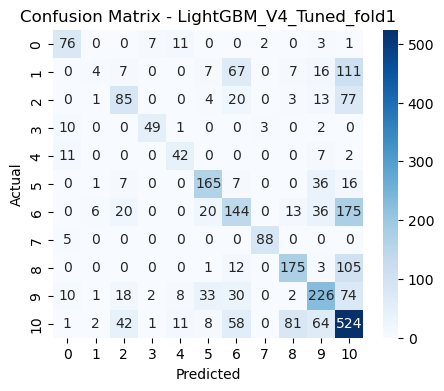

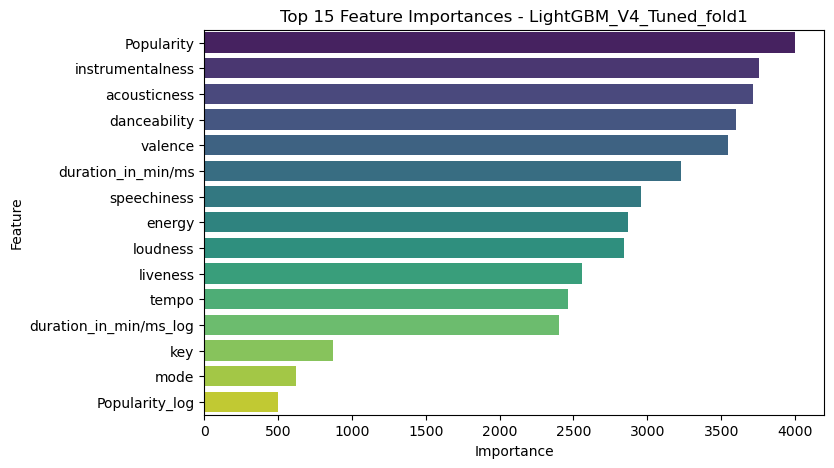

[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622

🔄 Fold 2/5
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.00

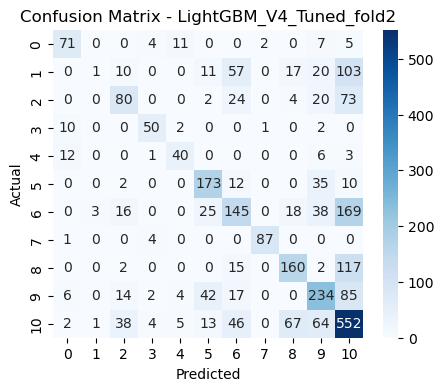

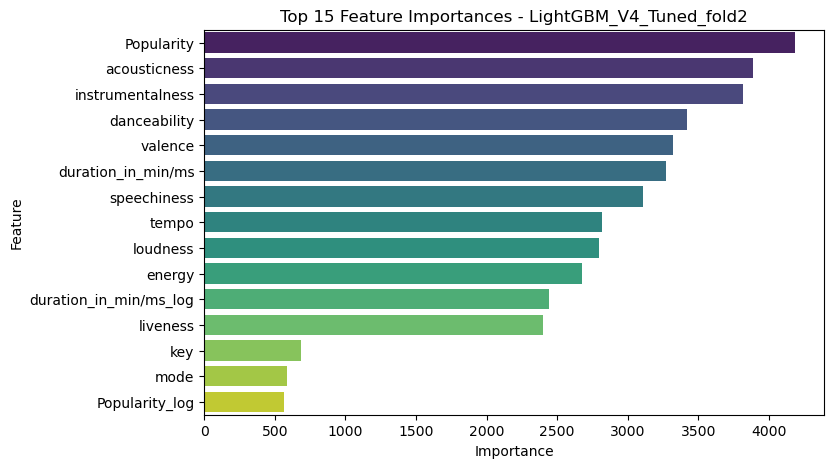

[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622

🔄 Fold 3/5
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.00

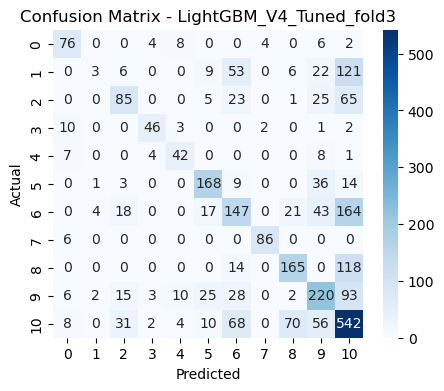

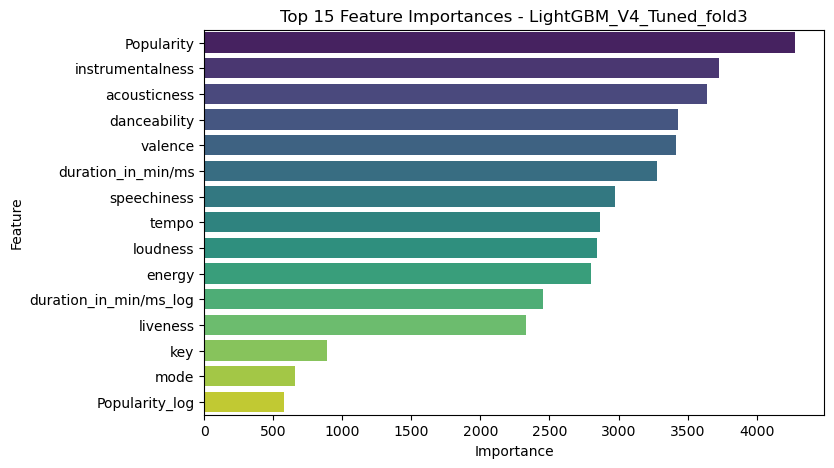

[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622

🔄 Fold 4/5
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.00

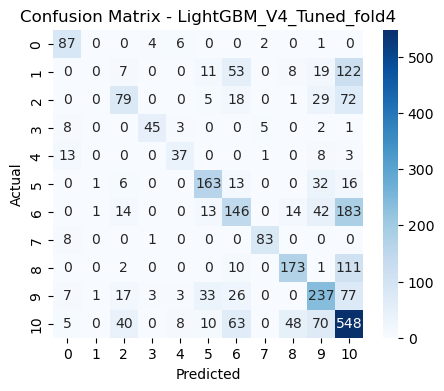

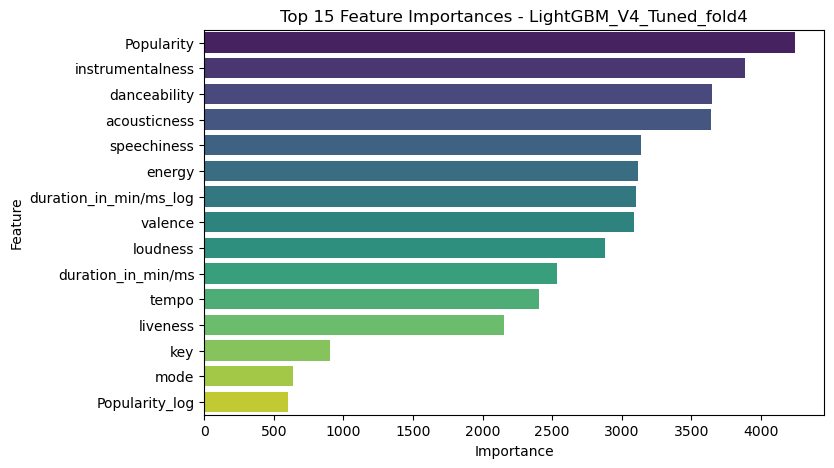

[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622

🔄 Fold 5/5
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.00

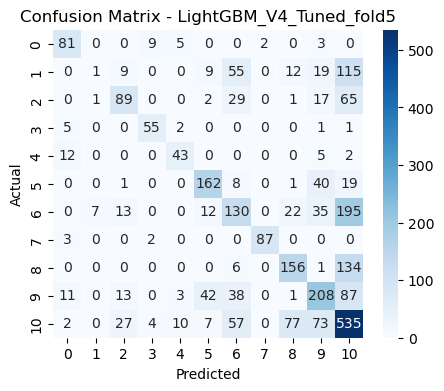

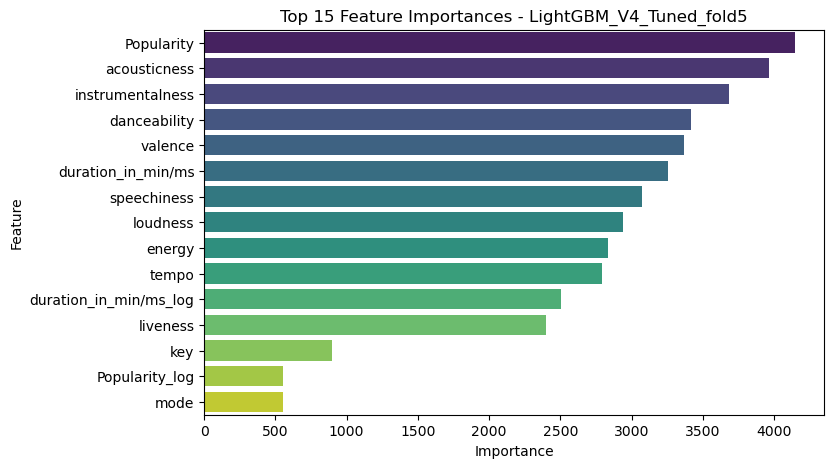

[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622
[LightGBM] [Warning] lambda_l1 is set=2.0177366860053736, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0177366860053736
[LightGBM] [Warning] lambda_l2 is set=0.006232257785977622, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.006232257785977622

📊 Average CV Metrics: {'Accuracy': 0.5484857299988422, 'Precision_macro': 0.593573678871285, 'Recall_macro': 0.5832204769370686, 'F1_macro': 0.5778588328555513, 'ROC_AUC_ovr_macro': 0.9047755941009978}
LightGBM Tuned CV F1-Macro: 0.5779

==================== Retraining XGBoost ====================

🚀 Start CV run: XGBoost_V4_Tuned_classification_CV_140921 (CV=5)

🔄 Fold 1/5

🔹 Evaluation Report for XGBoost_V4_Tuned_fold1 (classification)
              p

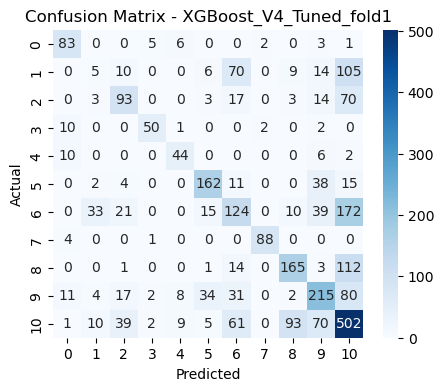

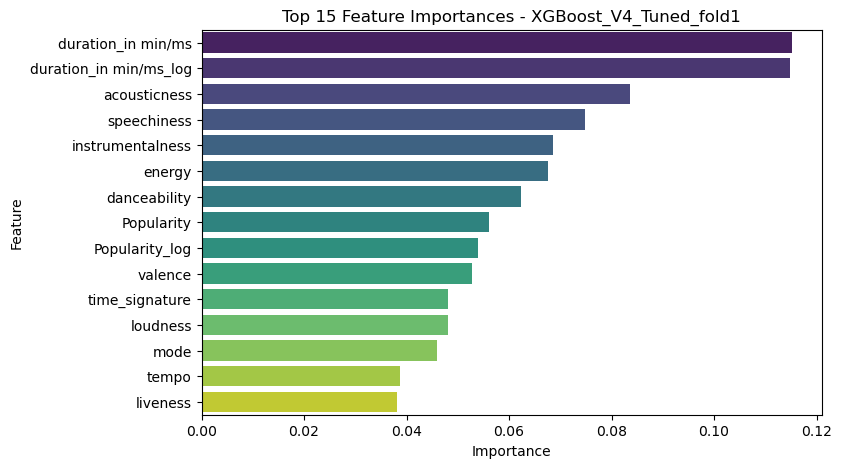


🔄 Fold 2/5

🔹 Evaluation Report for XGBoost_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       100
           1       0.11      0.02      0.04       219
           2       0.54      0.42      0.48       203
           3       0.82      0.71      0.76        65
           4       0.70      0.69      0.70        62
           5       0.66      0.75      0.70       232
           6       0.42      0.34      0.37       414
           7       0.95      0.93      0.94        92
           8       0.59      0.50      0.54       296
           9       0.55      0.56      0.55       404
          10       0.48      0.67      0.56       792

    accuracy                           0.54      2879
   macro avg       0.59      0.57      0.58      2879
weighted avg       0.52      0.54      0.52      2879


 Tổng hợp metrics:
                   XGBoost_V4_Tuned_fold2
Accuracy                         0.539076
Precis

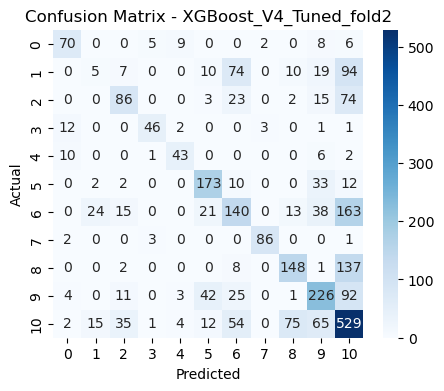

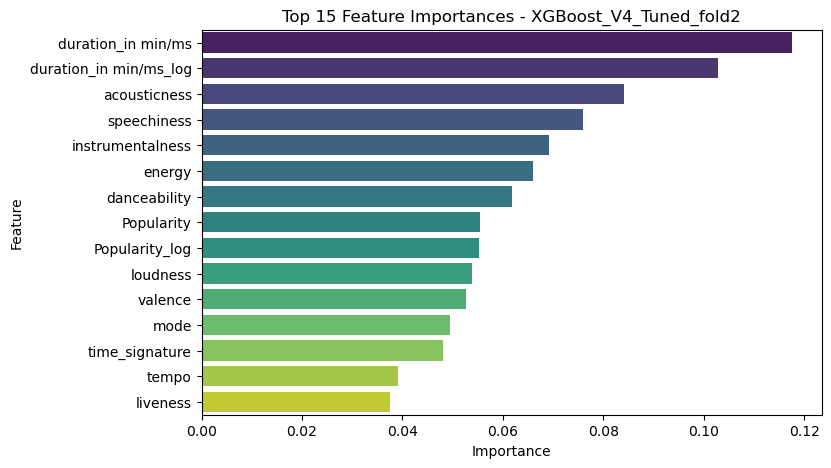


🔄 Fold 3/5

🔹 Evaluation Report for XGBoost_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       100
           1       0.14      0.04      0.06       220
           2       0.56      0.43      0.48       204
           3       0.78      0.73      0.76        64
           4       0.66      0.66      0.66        62
           5       0.75      0.74      0.75       231
           6       0.38      0.33      0.35       414
           7       0.92      0.92      0.92        92
           8       0.65      0.57      0.61       297
           9       0.56      0.56      0.56       404
          10       0.48      0.66      0.55       791

    accuracy                           0.54      2879
   macro avg       0.60      0.58      0.58      2879
weighted avg       0.53      0.54      0.53      2879


 Tổng hợp metrics:
                   XGBoost_V4_Tuned_fold3
Accuracy                         0.544286
Precis

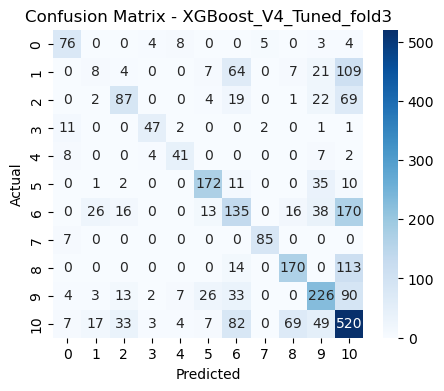

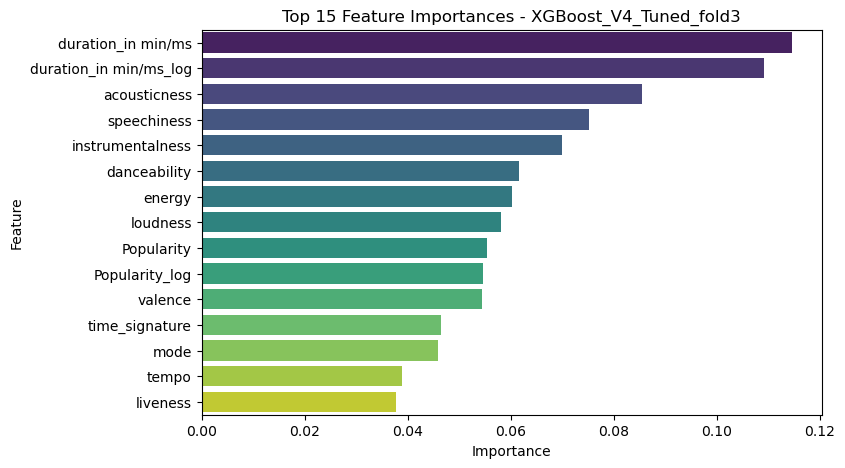


🔄 Fold 4/5

🔹 Evaluation Report for XGBoost_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.67      0.83      0.74       100
           1       0.08      0.01      0.02       220
           2       0.49      0.41      0.45       204
           3       0.87      0.70      0.78        64
           4       0.68      0.58      0.63        62
           5       0.70      0.70      0.70       231
           6       0.40      0.34      0.37       413
           7       0.92      0.91      0.92        92
           8       0.67      0.55      0.60       297
           9       0.55      0.57      0.56       404
          10       0.47      0.66      0.55       792

    accuracy                           0.54      2879
   macro avg       0.59      0.57      0.57      2879
weighted avg       0.52      0.54      0.52      2879


 Tổng hợp metrics:
                   XGBoost_V4_Tuned_fold4
Accuracy                         0.539076
Precis

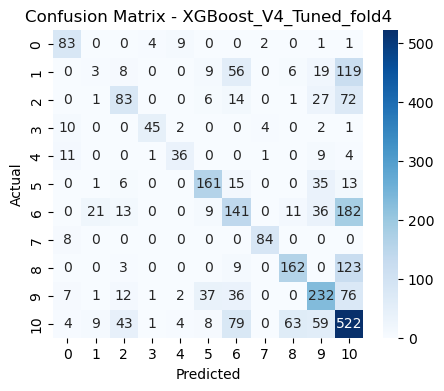

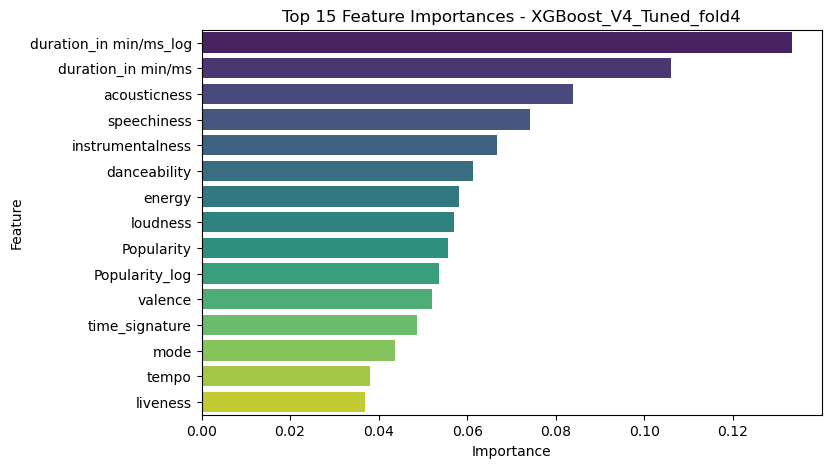


🔄 Fold 5/5

🔹 Evaluation Report for XGBoost_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       100
           1       0.08      0.02      0.03       220
           2       0.61      0.49      0.54       204
           3       0.85      0.86      0.85        64
           4       0.74      0.69      0.72        62
           5       0.72      0.71      0.71       231
           6       0.38      0.31      0.34       414
           7       0.98      0.93      0.96        92
           8       0.59      0.50      0.54       297
           9       0.54      0.53      0.53       403
          10       0.47      0.66      0.55       792

    accuracy                           0.54      2879
   macro avg       0.61      0.59      0.59      2879
weighted avg       0.52      0.54      0.52      2879


 Tổng hợp metrics:
                   XGBoost_V4_Tuned_fold5
Accuracy                         0.537339
Precis

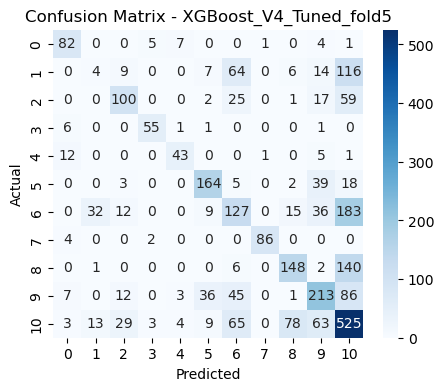

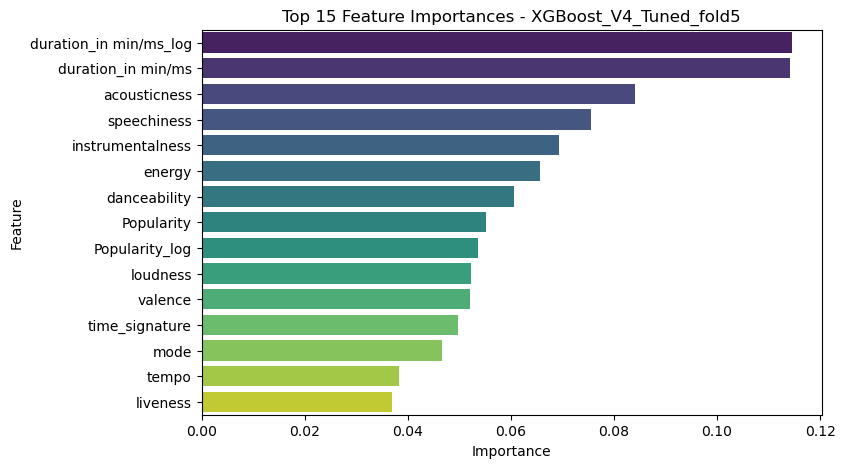


📊 Average CV Metrics: {'Accuracy': 0.538274984562541, 'Precision_macro': 0.5939324309181913, 'Recall_macro': 0.580733451617874, 'F1_macro': 0.5818249772499607, 'ROC_AUC_ovr_macro': 0.9011894229357627}
XGBoost Tuned CV F1-Macro: 0.5818

==================== Retraining CatBoost ====================

🚀 Start CV run: CatBoost_V4_Tuned_classification_CV_141050 (CV=5)

🔄 Fold 1/5
0:	learn: 2.3502978	test: 2.3515405	best: 2.3515405 (0)	total: 109ms	remaining: 1m 11s
100:	learn: 1.3562426	test: 1.3849976	best: 1.3849976 (100)	total: 1.76s	remaining: 9.72s
200:	learn: 1.2030726	test: 1.2679142	best: 1.2679142 (200)	total: 3.34s	remaining: 7.62s
300:	learn: 1.1218139	test: 1.2241096	best: 1.2241096 (300)	total: 4.94s	remaining: 5.89s
400:	learn: 1.0598989	test: 1.2026748	best: 1.2026748 (400)	total: 6.52s	remaining: 4.21s
500:	learn: 1.0098127	test: 1.1894603	best: 1.1894603 (500)	total: 8.16s	remaining: 2.59s
600:	learn: 0.9653379	test: 1.1800632	best: 1.1798555 (597)	total: 9.73s	remaining: 9

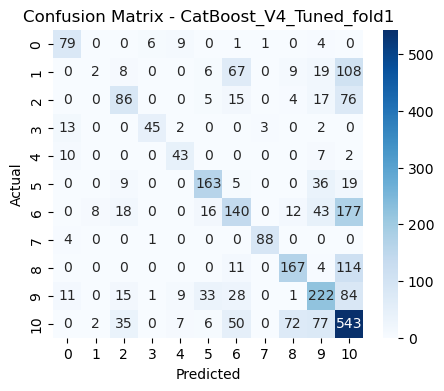

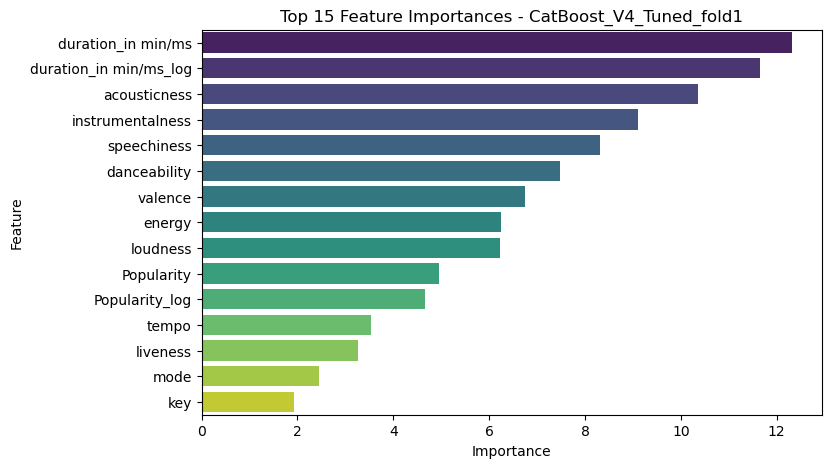


🔄 Fold 2/5
0:	learn: 2.3496224	test: 2.3512149	best: 2.3512149 (0)	total: 17.8ms	remaining: 11.7s
100:	learn: 1.3535033	test: 1.3951523	best: 1.3951523 (100)	total: 1.65s	remaining: 9.16s
200:	learn: 1.2005935	test: 1.2805384	best: 1.2805384 (200)	total: 3.26s	remaining: 7.45s
300:	learn: 1.1192268	test: 1.2375951	best: 1.2375951 (300)	total: 4.92s	remaining: 5.87s
400:	learn: 1.0609116	test: 1.2162442	best: 1.2162442 (400)	total: 6.57s	remaining: 4.24s
500:	learn: 1.0118450	test: 1.2018888	best: 1.2018888 (500)	total: 8.16s	remaining: 2.59s
600:	learn: 0.9668202	test: 1.1914465	best: 1.1914310 (599)	total: 9.74s	remaining: 956ms
659:	learn: 0.9433746	test: 1.1887667	best: 1.1887667 (659)	total: 10.7s	remaining: 0us

bestTest = 1.188766727
bestIteration = 659


🔹 Evaluation Report for CatBoost_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.66      0.65      0.66       100
           1       0.25      0.00      0.01       219

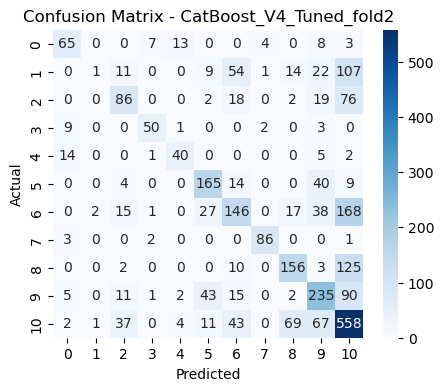

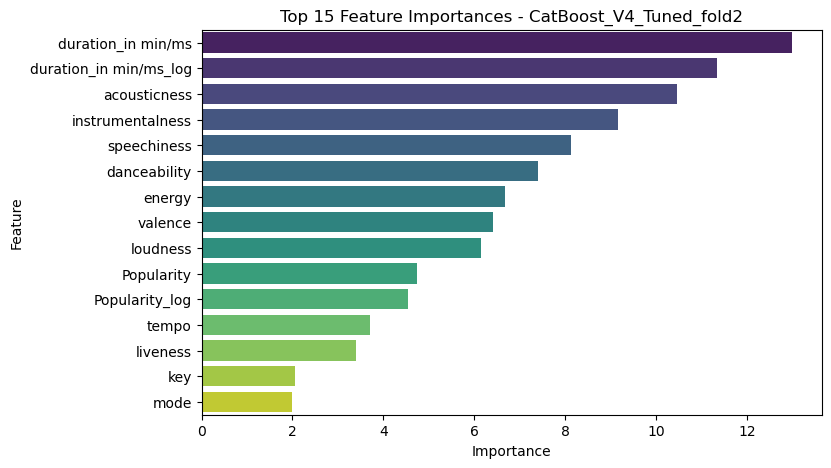


🔄 Fold 3/5
0:	learn: 2.3496105	test: 2.3517782	best: 2.3517782 (0)	total: 21.3ms	remaining: 14s
100:	learn: 1.3530153	test: 1.3906619	best: 1.3906619 (100)	total: 1.67s	remaining: 9.22s
200:	learn: 1.2021008	test: 1.2741740	best: 1.2741740 (200)	total: 3.24s	remaining: 7.39s
300:	learn: 1.1228892	test: 1.2302361	best: 1.2302361 (300)	total: 4.92s	remaining: 5.86s
400:	learn: 1.0645164	test: 1.2079773	best: 1.2079773 (400)	total: 6.46s	remaining: 4.17s
500:	learn: 1.0119308	test: 1.1931478	best: 1.1931478 (500)	total: 8.06s	remaining: 2.56s
600:	learn: 0.9681093	test: 1.1846357	best: 1.1846357 (600)	total: 9.65s	remaining: 948ms
659:	learn: 0.9440887	test: 1.1829156	best: 1.1829005 (655)	total: 10.6s	remaining: 0us

bestTest = 1.182900481
bestIteration = 655

Shrink model to first 656 iterations.

🔹 Evaluation Report for CatBoost_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       100
           1     

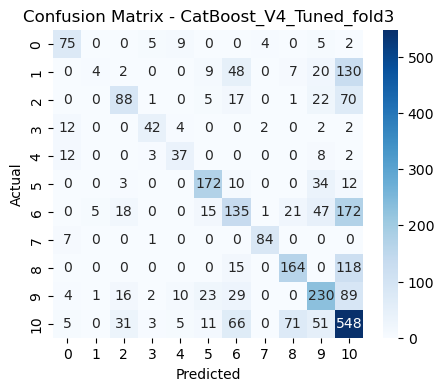

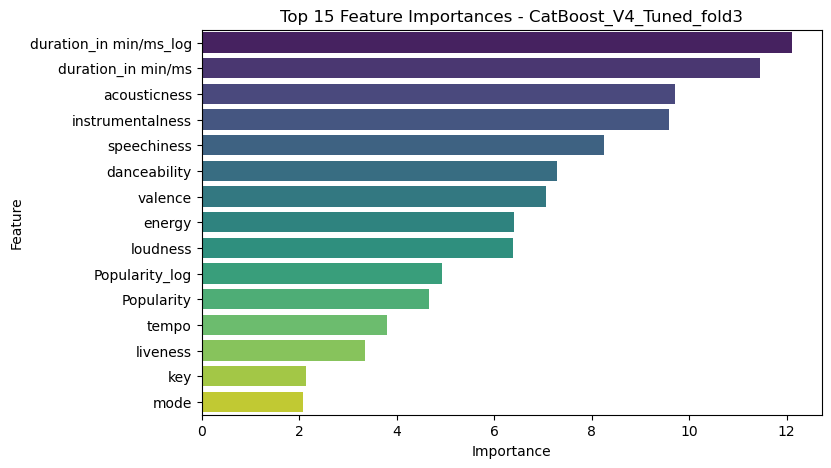


🔄 Fold 4/5
0:	learn: 2.3504109	test: 2.3500685	best: 2.3500685 (0)	total: 16.2ms	remaining: 10.6s
100:	learn: 1.3515423	test: 1.3879126	best: 1.3879126 (100)	total: 1.65s	remaining: 9.15s
200:	learn: 1.2004297	test: 1.2757666	best: 1.2757666 (200)	total: 3.25s	remaining: 7.43s
300:	learn: 1.1229302	test: 1.2351314	best: 1.2351314 (300)	total: 4.9s	remaining: 5.84s
400:	learn: 1.0632776	test: 1.2129236	best: 1.2129236 (400)	total: 6.53s	remaining: 4.22s
500:	learn: 1.0125417	test: 1.1979759	best: 1.1979759 (500)	total: 8.14s	remaining: 2.58s
600:	learn: 0.9673899	test: 1.1887037	best: 1.1887037 (600)	total: 9.75s	remaining: 957ms
659:	learn: 0.9424743	test: 1.1855529	best: 1.1855529 (659)	total: 10.7s	remaining: 0us

bestTest = 1.185552868
bestIteration = 659


🔹 Evaluation Report for CatBoost_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.68      0.81      0.74       100
           1       0.14      0.00      0.01       220


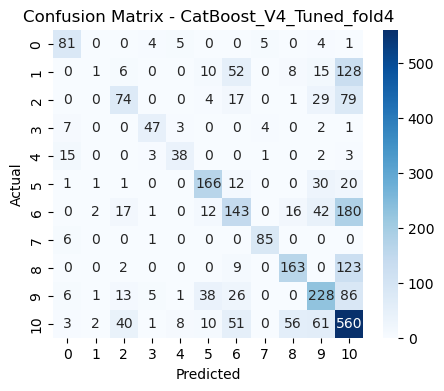

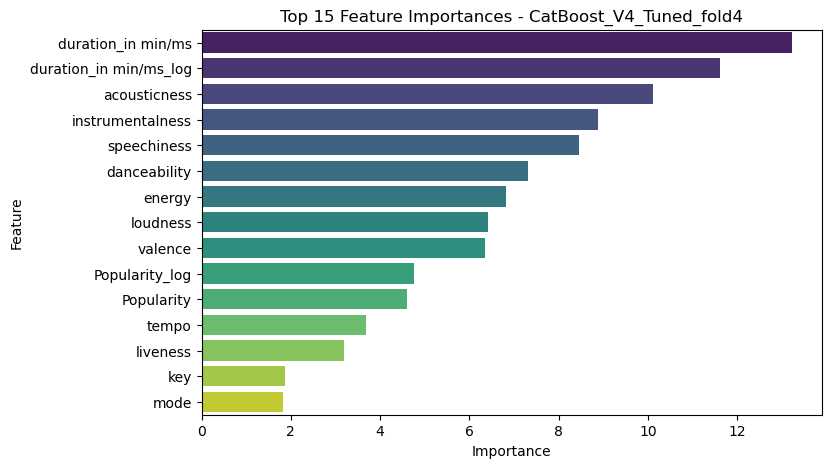


🔄 Fold 5/5
0:	learn: 2.3500212	test: 2.3513697	best: 2.3513697 (0)	total: 18ms	remaining: 11.9s
100:	learn: 1.3500056	test: 1.4054098	best: 1.4054098 (100)	total: 1.7s	remaining: 9.43s
200:	learn: 1.1983522	test: 1.2917175	best: 1.2917175 (200)	total: 3.31s	remaining: 7.55s
300:	learn: 1.1183559	test: 1.2483197	best: 1.2483197 (300)	total: 4.93s	remaining: 5.88s
400:	learn: 1.0583015	test: 1.2259645	best: 1.2259645 (400)	total: 6.52s	remaining: 4.21s
500:	learn: 1.0058610	test: 1.2113608	best: 1.2113608 (500)	total: 8.15s	remaining: 2.59s
600:	learn: 0.9593947	test: 1.2021525	best: 1.2021525 (600)	total: 9.72s	remaining: 954ms
659:	learn: 0.9345717	test: 1.1987188	best: 1.1986013 (657)	total: 10.7s	remaining: 0us

bestTest = 1.198601315
bestIteration = 657

Shrink model to first 658 iterations.

🔹 Evaluation Report for CatBoost_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       100
           1      

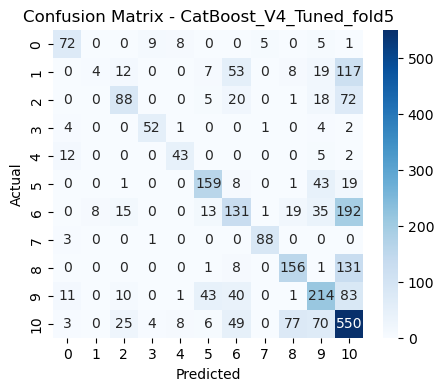

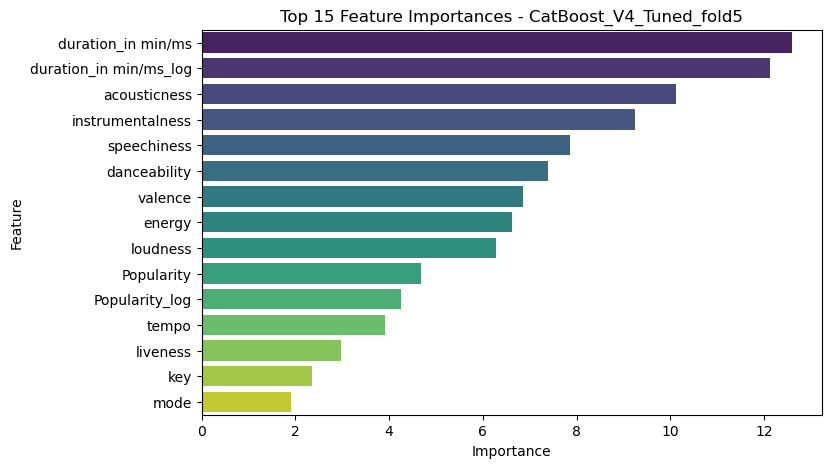


📊 Average CV Metrics: {'Accuracy': 0.5479299814750492, 'Precision_macro': 0.5995024397536171, 'Recall_macro': 0.5758396688917903, 'F1_macro': 0.5732151456399834, 'ROC_AUC_ovr_macro': 0.9060348690070457}
CatBoost Tuned CV F1-Macro: 0.5732

==================== Retraining RandomForest ====================

🚀 Start CV run: RandomForest_V4_Tuned_classification_CV_141146 (CV=5)

🔄 Fold 1/5
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest_V4_Tuned_fold1 (classification)
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       100
           1       0.07      0.01      0.02       219
           2       0.55      0.32      0.40       203
           3       0.83      0.74      0.78        65
           4       0.66      0.71      0.68        62
           5       0.70      0.68      0.69       232
           6       0.40      0.31      0.35       414
           7       0.96      0.94      0.95        93
           8    

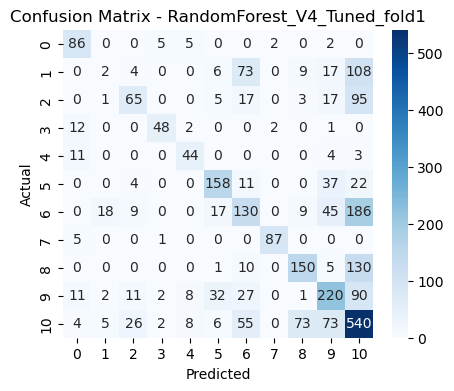

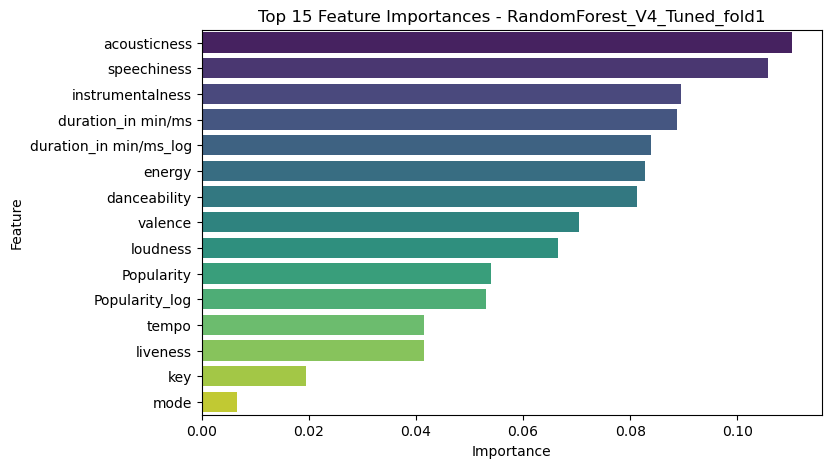

💾 Model đã được lưu tại: experiments/models\RandomForest_V4_Tuned_fold1_best.pkl

🔄 Fold 2/5
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       100
           1       0.11      0.01      0.02       219
           2       0.57      0.31      0.40       203
           3       0.79      0.68      0.73        65
           4       0.70      0.63      0.66        62
           5       0.63      0.70      0.66       232
           6       0.42      0.31      0.36       414
           7       0.96      0.93      0.95        92
           8       0.61      0.45      0.52       296
           9       0.52      0.56      0.54       404
          10       0.46      0.71      0.56       792

    accuracy                           0.53      2879
   macro avg       0.58      0.55      0.55      2879
weighted avg       0.51      0.53      0.

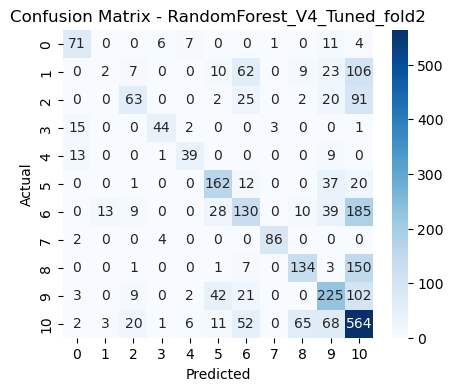

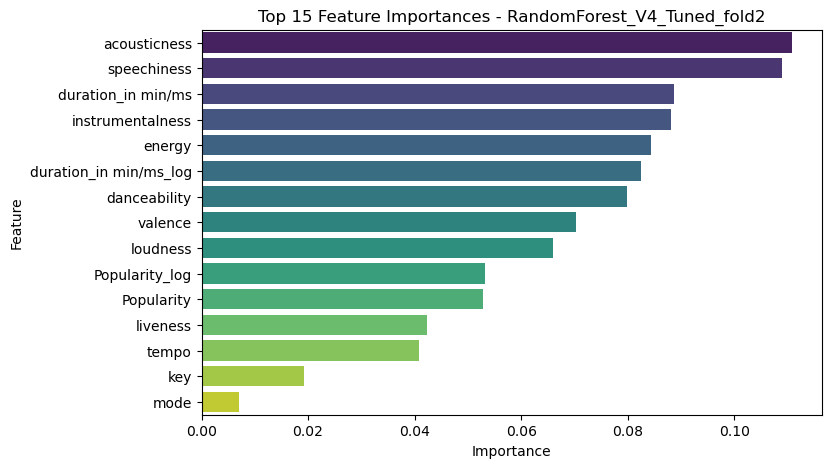

💾 Model đã được lưu tại: experiments/models\RandomForest_V4_Tuned_fold2_best.pkl

🔄 Fold 3/5
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.67      0.80      0.73       100
           1       0.26      0.02      0.04       220
           2       0.57      0.29      0.39       204
           3       0.78      0.72      0.75        64
           4       0.59      0.68      0.63        62
           5       0.74      0.73      0.73       231
           6       0.40      0.32      0.36       414
           7       0.93      0.93      0.93        92
           8       0.65      0.51      0.57       297
           9       0.53      0.53      0.53       404
          10       0.45      0.70      0.55       791

    accuracy                           0.53      2879
   macro avg       0.60      0.57      0.56      2879
weighted avg       0.53      0.53      0.

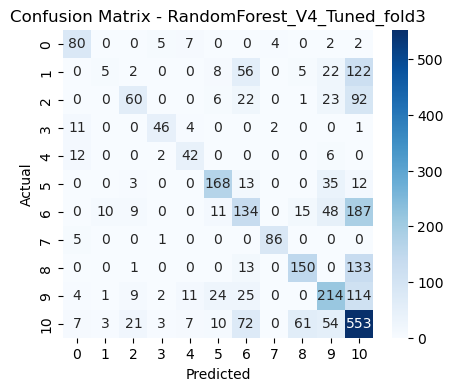

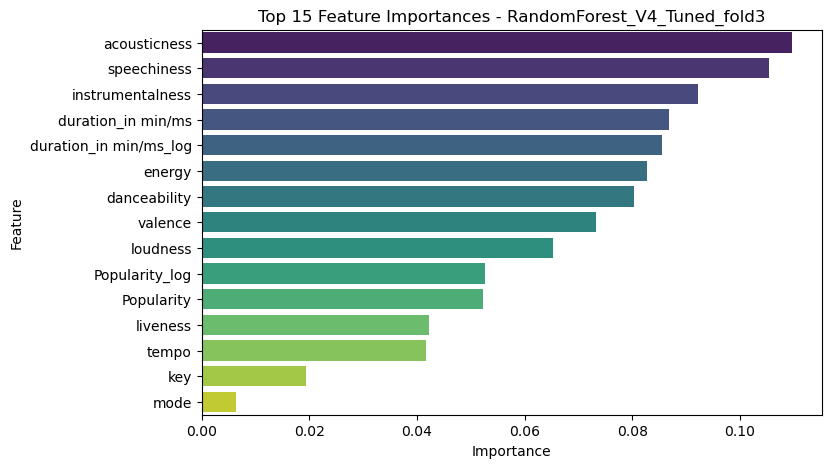

💾 Model đã được lưu tại: experiments/models\RandomForest_V4_Tuned_fold3_best.pkl

🔄 Fold 4/5
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       100
           1       0.17      0.01      0.02       220
           2       0.53      0.32      0.40       204
           3       0.85      0.72      0.78        64
           4       0.62      0.52      0.56        62
           5       0.70      0.71      0.71       231
           6       0.40      0.31      0.35       413
           7       0.94      0.92      0.93        92
           8       0.70      0.53      0.60       297
           9       0.53      0.54      0.54       404
          10       0.45      0.71      0.55       792

    accuracy                           0.54      2879
   macro avg       0.60      0.56      0.56      2879
weighted avg       0.52      0.54      0.

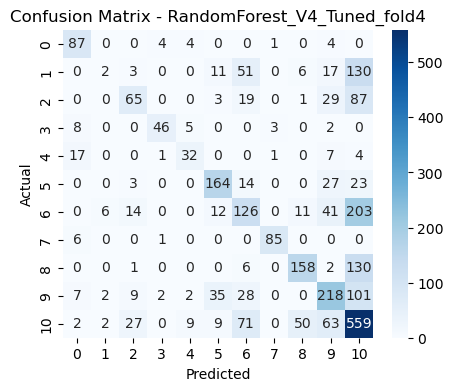

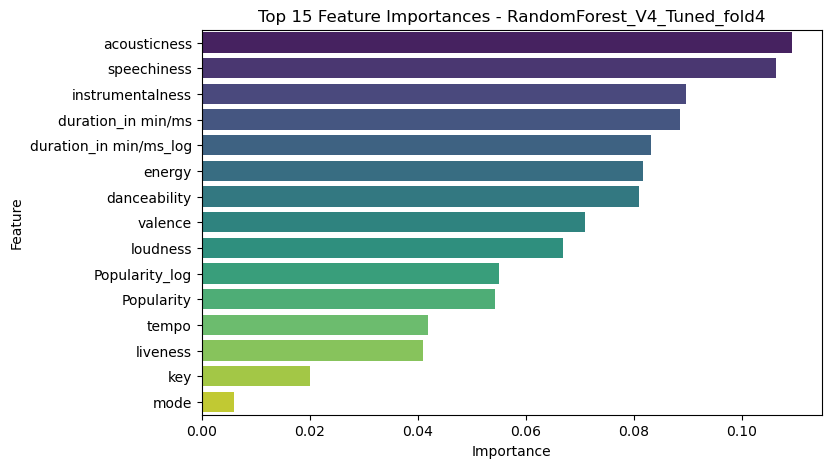

💾 Model đã được lưu tại: experiments/models\RandomForest_V4_Tuned_fold4_best.pkl

🔄 Fold 5/5
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for RandomForest_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.66      0.77      0.71       100
           1       0.27      0.03      0.05       220
           2       0.62      0.32      0.42       204
           3       0.76      0.80      0.78        64
           4       0.69      0.65      0.67        62
           5       0.71      0.68      0.70       231
           6       0.36      0.26      0.30       414
           7       0.96      0.96      0.96        92
           8       0.60      0.47      0.53       297
           9       0.50      0.50      0.50       403
          10       0.45      0.72      0.55       792

    accuracy                           0.52      2879
   macro avg       0.60      0.56      0.56      2879
weighted avg       0.52      0.52      0.

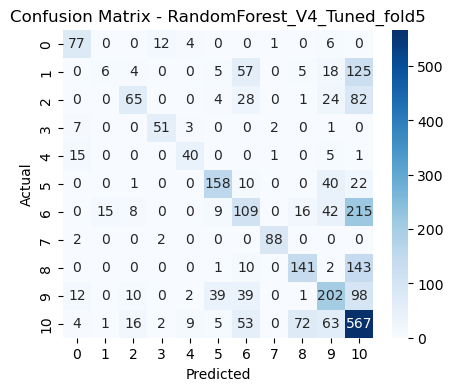

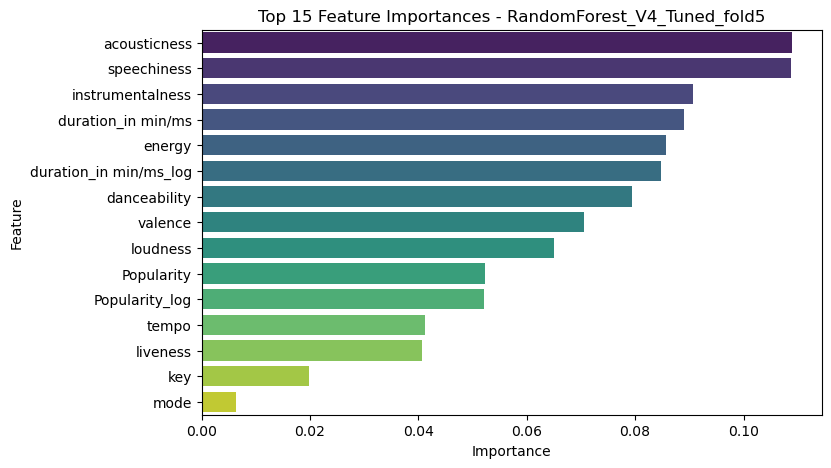

💾 Model đã được lưu tại: experiments/models\RandomForest_V4_Tuned_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.5302861236540466, 'Precision_macro': 0.592832442510369, 'Recall_macro': 0.5607375349775234, 'F1_macro': 0.5622966113731172, 'ROC_AUC_ovr_macro': 0.8957496561781817}
RandomForest Tuned CV F1-Macro: 0.5623

==================== Retraining SVM ====================

🚀 Start CV run: SVM_V4_Tuned_classification_CV_141156 (CV=5)

🔄 Fold 1/5
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V4_Tuned_fold1 (classification)
              precision    recall  f1-score   support

           0       0.63      0.78      0.70       100
           1       0.18      0.03      0.05       219
           2       0.44      0.36      0.40       203
           3       0.80      0.60      0.68        65
           4       0.60      0.66      0.63        62
           5       0.69      0.67      0.68       232
           6       0.39      0.27      0.32       414
           7       0.95

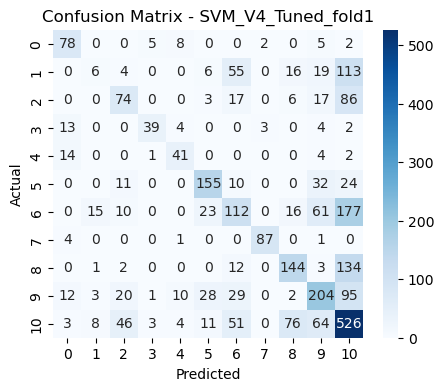

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V4_Tuned_fold1_best.pkl

🔄 Fold 2/5
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.64      0.67      0.65       100
           1       0.31      0.04      0.07       219
           2       0.51      0.36      0.43       203
           3       0.80      0.75      0.78        65
           4       0.61      0.60      0.60        62
           5       0.61      0.67      0.64       232
           6       0.39      0.28      0.33       414
           7       0.94      0.91      0.93        92
           8       0.61      0.45      0.51       296
           9       0.49      0.52      0.51       404
          10       0.46      0.70      0.56       792

    accuracy                           0.52      2879
   macro avg       0.58      0.54      0.55      2879
weighted avg       

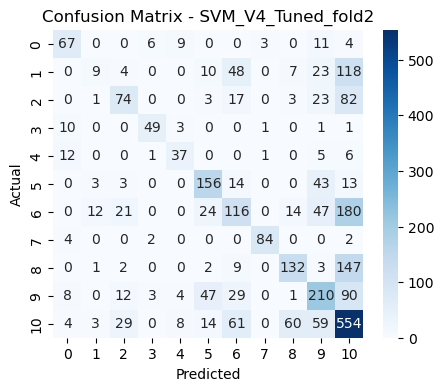

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V4_Tuned_fold2_best.pkl

🔄 Fold 3/5
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       100
           1       0.16      0.02      0.04       220
           2       0.48      0.39      0.43       204
           3       0.72      0.69      0.70        64
           4       0.61      0.68      0.64        62
           5       0.69      0.70      0.70       231
           6       0.37      0.26      0.31       414
           7       0.92      0.88      0.90        92
           8       0.59      0.52      0.55       297
           9       0.53      0.54      0.54       404
          10       0.46      0.67      0.55       791

    accuracy                           0.52      2879
   macro avg       0.57      0.56      0.55      2879
weighted avg       

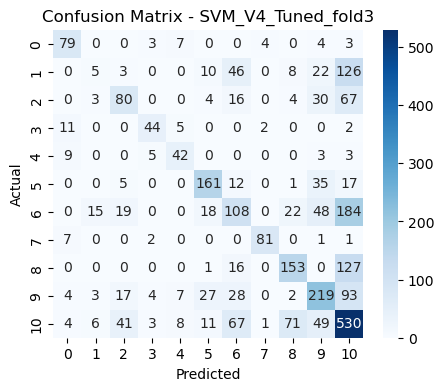

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V4_Tuned_fold3_best.pkl

🔄 Fold 4/5
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.63      0.81      0.71       100
           1       0.12      0.02      0.03       220
           2       0.46      0.37      0.41       204
           3       0.78      0.72      0.75        64
           4       0.62      0.58      0.60        62
           5       0.68      0.71      0.69       231
           6       0.42      0.28      0.34       413
           7       0.91      0.86      0.88        92
           8       0.66      0.49      0.56       297
           9       0.52      0.52      0.52       404
          10       0.46      0.70      0.56       792

    accuracy                           0.53      2879
   macro avg       0.57      0.55      0.55      2879
weighted avg       

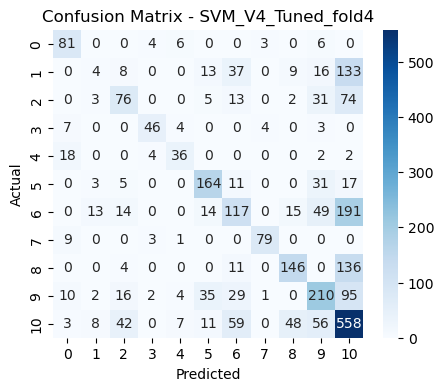

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V4_Tuned_fold4_best.pkl

🔄 Fold 5/5
🚀 Huấn luyện mô hình SVM...

🔹 Evaluation Report for SVM_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.64      0.69      0.66       100
           1       0.18      0.03      0.05       220
           2       0.58      0.41      0.48       204
           3       0.78      0.72      0.75        64
           4       0.62      0.73      0.67        62
           5       0.64      0.68      0.66       231
           6       0.37      0.25      0.30       414
           7       0.93      0.90      0.92        92
           8       0.57      0.44      0.50       297
           9       0.50      0.48      0.49       403
          10       0.45      0.70      0.55       792

    accuracy                           0.51      2879
   macro avg       0.57      0.55      0.55      2879
weighted avg       

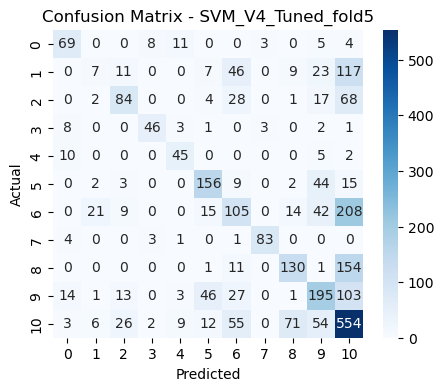

⚠️ Mô hình không có thông tin feature importance.
💾 Model đã được lưu tại: experiments/models\SVM_V4_Tuned_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.517297045656285, 'Precision_macro': 0.5695419575258989, 'Recall_macro': 0.5482498778419668, 'F1_macro': 0.5479741099336441, 'ROC_AUC_ovr_macro': 0.8942387979537976}
SVM Tuned CV F1-Macro: 0.5480

==================== Retraining KNN ====================

🚀 Start CV run: KNN_V4_Tuned_classification_CV_141403 (CV=5)

🔄 Fold 1/5

🔹 Evaluation Report for KNN_V4_Tuned_fold1 (classification)
              precision    recall  f1-score   support

           0       0.63      0.78      0.70       100
           1       0.20      0.08      0.11       219
           2       0.43      0.37      0.40       203
           3       0.76      0.65      0.70        65
           4       0.54      0.61      0.58        62
           5       0.69      0.67      0.68       232
           6       0.33      0.28      0.30       414
           7       

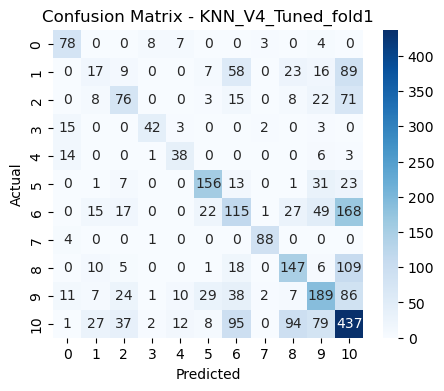

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V4_Tuned_fold1_best.pkl

🔄 Fold 2/5

🔹 Evaluation Report for KNN_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       100
           1       0.15      0.06      0.09       219
           2       0.38      0.33      0.35       203
           3       0.76      0.65      0.70        65
           4       0.54      0.65      0.59        62
           5       0.65      0.66      0.65       232
           6       0.34      0.27      0.30       414
           7       0.95      0.90      0.93        92
           8       0.49      0.49      0.49       296
           9       0.44      0.45      0.45       404
          10       0.45      0.57      0.50       792

    accuracy                           0.47      2879
   macro avg       0.52      0.52      0.52      2879
weighted avg       0.45      0.47      0.46   

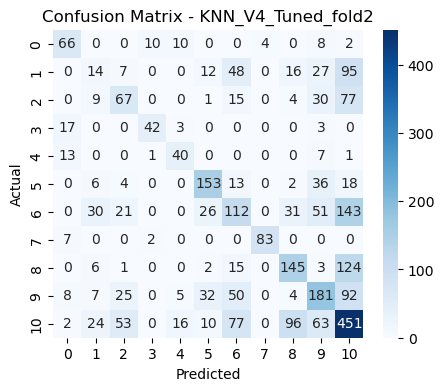

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V4_Tuned_fold2_best.pkl

🔄 Fold 3/5

🔹 Evaluation Report for KNN_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.61      0.78      0.68       100
           1       0.14      0.05      0.07       220
           2       0.38      0.36      0.37       204
           3       0.83      0.62      0.71        64
           4       0.48      0.65      0.55        62
           5       0.72      0.68      0.70       231
           6       0.30      0.23      0.26       414
           7       0.90      0.91      0.91        92
           8       0.51      0.51      0.51       297
           9       0.45      0.46      0.46       404
          10       0.44      0.56      0.49       791

    accuracy                           0.47      2879
   macro avg       0.52      0.53      0.52      2879
weighted avg       0.45      0.47      0.46   

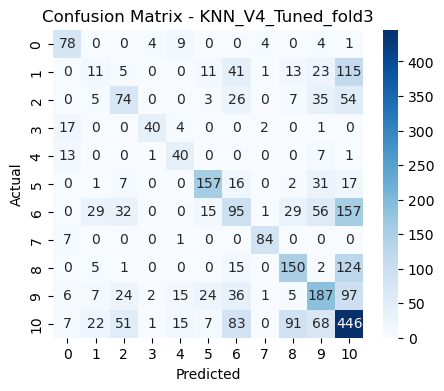

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V4_Tuned_fold3_best.pkl

🔄 Fold 4/5

🔹 Evaluation Report for KNN_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.59      0.78      0.67       100
           1       0.15      0.05      0.08       220
           2       0.37      0.31      0.34       204
           3       0.74      0.62      0.68        64
           4       0.51      0.56      0.54        62
           5       0.71      0.68      0.69       231
           6       0.37      0.29      0.32       413
           7       0.89      0.90      0.90        92
           8       0.50      0.43      0.46       297
           9       0.45      0.46      0.45       404
          10       0.44      0.59      0.51       792

    accuracy                           0.48      2879
   macro avg       0.52      0.52      0.51      2879
weighted avg       0.46      0.48      0.46   

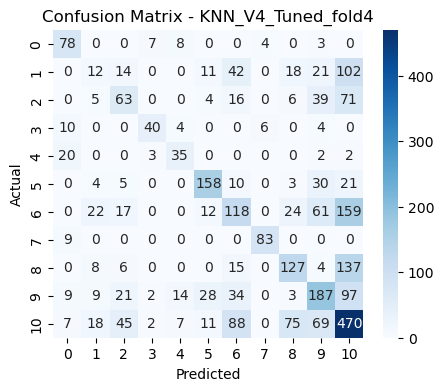

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V4_Tuned_fold4_best.pkl

🔄 Fold 5/5

🔹 Evaluation Report for KNN_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.57      0.73      0.64       100
           1       0.16      0.07      0.10       220
           2       0.44      0.38      0.41       204
           3       0.80      0.67      0.73        64
           4       0.47      0.60      0.52        62
           5       0.65      0.64      0.65       231
           6       0.30      0.25      0.27       414
           7       0.92      0.90      0.91        92
           8       0.49      0.47      0.48       297
           9       0.44      0.42      0.43       403
          10       0.43      0.55      0.48       792

    accuracy                           0.46      2879
   macro avg       0.52      0.52      0.51      2879
weighted avg       0.45      0.46      0.45   

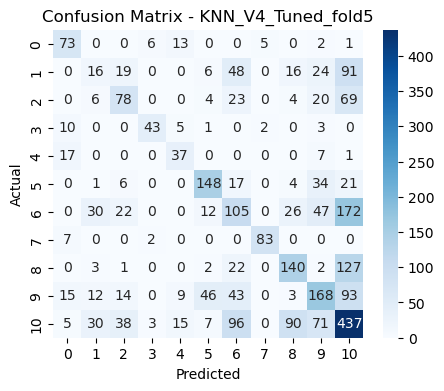

⚠️ Mô hình không có thông tin feature importance.
💾 Mô hình KNN đã lưu tại: experiments/models\KNN_V4_Tuned_fold5_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.47221394870904254, 'Precision_macro': 0.5235057336456135, 'Recall_macro': 0.5233502470285945, 'F1_macro': 0.5183087346674938, 'ROC_AUC_ovr_macro': 0.8495492117240021}
KNN Tuned CV F1-Macro: 0.5183

==================== Retraining NaiveBayes ====================

🚀 Start CV run: NaiveBayes_V4_Tuned_classification_CV_141406 (CV=5)

🔄 Fold 1/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V4_Tuned_fold1 (classification)
              precision    recall  f1-score   support

           0       0.62      0.69      0.65       100
           1       0.12      0.21      0.16       219
           2       0.32      0.41      0.36       203
           3       0.61      0.60      0.60        65
           4       0.39      0.94      0.55        62
           5       0.38      0.78      0.51       232
  

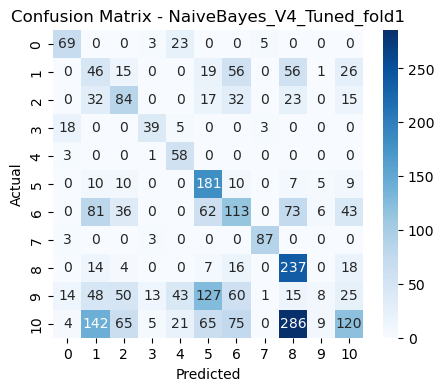

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V4_Tuned_fold1_gaussian_best.pkl

🔄 Fold 2/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V4_Tuned_fold2 (classification)
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       100
           1       0.12      0.16      0.13       219
           2       0.33      0.48      0.39       203
           3       0.38      0.49      0.43        65
           4       0.37      0.81      0.51        62
           5       0.38      0.83      0.52       232
           6       0.34      0.29      0.31       414
           7       0.88      0.89      0.89        92
           8       0.34      0.81      0.48       296
           9       0.44      0.04      0.08       404
          10       0.51      0.19      0.27       792

    accuracy                           0.37      2879
   macro avg       0.42 

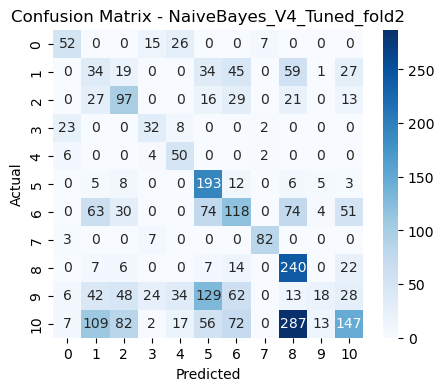

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V4_Tuned_fold2_gaussian_best.pkl

🔄 Fold 3/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V4_Tuned_fold3 (classification)
              precision    recall  f1-score   support

           0       0.51      0.56      0.54       100
           1       0.17      0.23      0.20       220
           2       0.29      0.46      0.36       204
           3       0.51      0.50      0.50        64
           4       0.34      0.84      0.48        62
           5       0.40      0.83      0.54       231
           6       0.30      0.24      0.26       414
           7       0.93      0.95      0.94        92
           8       0.36      0.83      0.50       297
           9       0.26      0.02      0.04       404
          10       0.51      0.20      0.29       791

    accuracy                           0.37      2879
   macro avg       0.42 

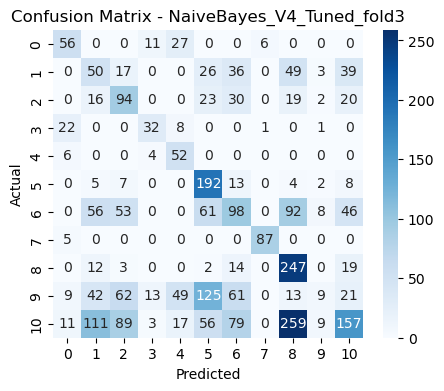

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V4_Tuned_fold3_gaussian_best.pkl

🔄 Fold 4/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V4_Tuned_fold4 (classification)
              precision    recall  f1-score   support

           0       0.53      0.63      0.58       100
           1       0.15      0.16      0.15       220
           2       0.28      0.48      0.36       204
           3       0.53      0.52      0.52        64
           4       0.40      0.84      0.54        62
           5       0.38      0.80      0.52       231
           6       0.36      0.29      0.32       413
           7       0.82      0.87      0.84        92
           8       0.36      0.80      0.50       297
           9       0.34      0.03      0.06       404
          10       0.46      0.21      0.29       792

    accuracy                           0.38      2879
   macro avg       0.42 

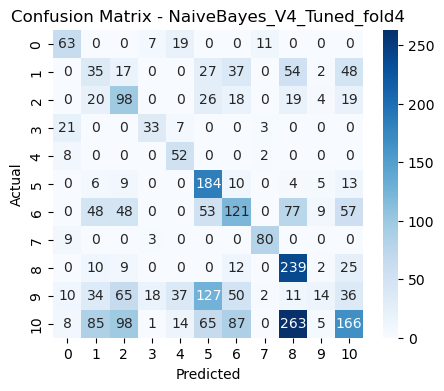

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V4_Tuned_fold4_gaussian_best.pkl

🔄 Fold 5/5
🚀 Huấn luyện mô hình Naive Bayes (gaussian)...

🔹 Evaluation Report for NaiveBayes_V4_Tuned_fold5 (classification)
              precision    recall  f1-score   support

           0       0.54      0.46      0.50       100
           1       0.14      0.21      0.17       220
           2       0.33      0.50      0.40       204
           3       0.56      0.70      0.62        64
           4       0.34      0.84      0.49        62
           5       0.42      0.80      0.55       231
           6       0.32      0.27      0.30       414
           7       0.89      0.95      0.92        92
           8       0.34      0.77      0.47       297
           9       0.46      0.05      0.09       403
          10       0.50      0.20      0.29       792

    accuracy                           0.38      2879
   macro avg       0.44 

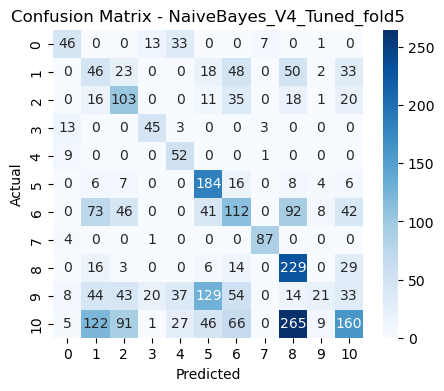

⚠️ Mô hình không có thông tin feature importance.
💾 Model Naive Bayes đã lưu tại: experiments/models\NaiveBayes_V4_Tuned_fold5_gaussian_best.pkl

📊 Average CV Metrics: {'Accuracy': 0.3715622226081587, 'Precision_macro': 0.4252484668431519, 'Recall_macro': 0.5154409616085418, 'F1_macro': 0.4261590330718814, 'ROC_AUC_ovr_macro': 0.8552249869920558}
NaiveBayes Tuned CV F1-Macro: 0.4262


In [4]:
models = {
    "LightGBM": (ModelLightGBM, best_params_lgbm),
    "XGBoost": (ModelXGBoost, best_params_xgb),
    "CatBoost": (ModelCatboost, best_params_cat),
    "RandomForest": (ModelRandomForest, best_params_rf),
    "SVM": (ModelSVM, best_params_svm),
    "KNN": (ModelKNN, best_params_knn),
    "NaiveBayes": (ModelNaiveBayes, best_params_nb)
}

oof_preds = {}
test_preds = {}
model_metrics = {}

CV_FOLDS = 5

# Prepare DF for Pipeline
temp_df = pd.concat([X_selected, y.rename(target_col)], axis=1)

for name, (model_cls, params) in models.items():
    print(f"\n{'='*20} Retraining {name} {'='*20}")
    
    pipeline = BasePipeline(model_cls, experiment_name="Music_V4")
    
    oof, test_p, metrics = pipeline.run_cv(
        df=temp_df, 
        target_col=target_col, 
        task="classification", 
        model_name=f"{name}_V4_Tuned", 
        cv=CV_FOLDS,
        test_df=X_test_selected,
        model_params=params # Pass tuned params here
    )
    
    oof_preds[name] = oof
    test_preds[name] = test_p
    model_metrics[name] = metrics
    
    print(f"{name} Tuned CV F1-Macro: {metrics.get('F1_macro', 0):.4f}")

## 4. Model Comparison (Tuned)

In [5]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values("F1_macro", ascending=False)
display(metrics_df[['F1_macro', 'Accuracy', 'Precision_macro', 'Recall_macro']])

,F1_macro,Accuracy,Precision_macro,Recall_macro
XGBoost,0.581825,0.538275,0.593932,0.580733
LightGBM,0.577859,0.548486,0.593574,0.583220
CatBoost,0.573215,0.547930,0.599502,0.575840
RandomForest,0.562297,0.530286,0.592832,0.560738
SVM,0.547974,0.517297,0.569542,0.548250
KNN,0.518309,0.472214,0.523506,0.523350
NaiveBayes,0.426159,0.371562,0.425248,0.515441


## 5. Ensemble Refinement (Weighted Soft Voting)

In [6]:
ensemble = Ensemble(models=[], task="classification") # Helper instance

# Optimize weights
best_weights = ensemble.optimize_weights(oof_preds, y)

print("\n✅ Optimized Weights:")
for m, w in best_weights.items():
    print(f"{m}: {w:.4f}")

# Calculate Ensemble Score
final_prob = np.zeros_like(oof_preds["LightGBM"])
for m, w in best_weights.items():
    final_prob += w * oof_preds[m]

y_pred_ens = np.argmax(final_prob, axis=1)
ens_f1 = f1_score(y, y_pred_ens, average='macro')
print(f"\n🏆 Ensemble CV F1-Macro: {ens_f1:.4f}")


✅ Optimized Weights:
LightGBM: 0.1429
XGBoost: 0.1429
CatBoost: 0.1429
RandomForest: 0.1429
SVM: 0.1429
KNN: 0.1429
NaiveBayes: 0.1429

🏆 Ensemble CV F1-Macro: 0.5741


## 6. Final Submission

In [7]:
# Weighted sum of test probabilities
final_test_prob = np.zeros_like(test_preds["LightGBM"])
for m, w in best_weights.items():
    final_test_prob += w * test_preds[m]

final_test_pred = np.argmax(final_test_prob, axis=1)
final_labels = le.inverse_transform(final_test_pred)

# Create Submission
submission = pd.DataFrame({
    'Id': pd.read_csv(os.path.join(DATA_DIR, "test.csv"))['Id'],
    'Class': final_labels
})

os.makedirs("experiments/Music_V4", exist_ok=True)
sub_path = "experiments/Music_V4/submission_music_v4_tuned_ensemble.csv"
submission.to_csv(sub_path, index=False)

print(f"✅ Submission saved to {sub_path}")
submission.head()

✅ Submission saved to experiments/Music_V4/submission_music_v4_tuned_ensemble.csv


,Id,Class
0,14397,9
1,14398,6
2,14399,9
3,14400,10
4,14401,5


In [8]:
# Save Artifacts
artifacts = {
    "best_weights": best_weights,
    "metrics": metrics_df.to_dict(),
    "best_params": {
        "LightGBM": best_params_lgbm,
        "XGBoost": best_params_xgb,
        "CatBoost": best_params_cat,
        "RandomForest": best_params_rf,
        "SVM": best_params_svm,
        "KNN": best_params_knn
    }
}

with open("experiments/Music_V4/artifacts_v4.json", "w") as f:
    json.dump(artifacts, f, indent=4)

print("✅ Artifacts saved.")

✅ Artifacts saved.
